# Análisis Exploratorio de Datos (EDA)

Exploraremos los datos limpios para comprender las relaciones entre las variables de supervivenia.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('data/titanic_clean.csv')
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


# Supervivencia por Género

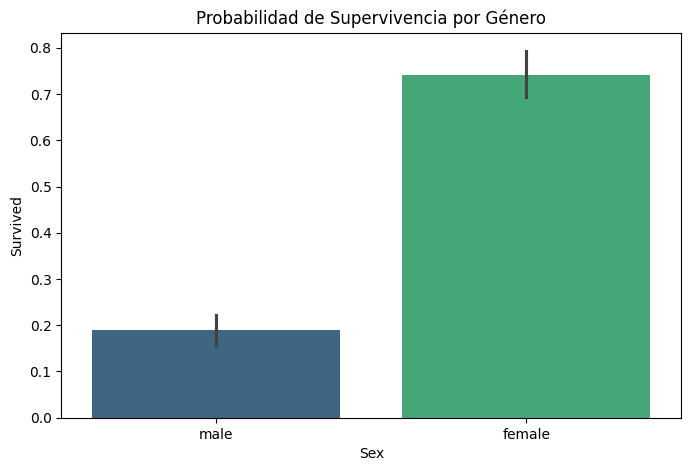

In [2]:
plt.figure(figsize=(8,5))
sns.barplot(
    x='Sex',
    y='Survived',
    hue='Sex',
    data=df,
    palette='viridis',
    legend=False
)
plt.title('Probabilidad de Supervivencia por Género')
plt.show()

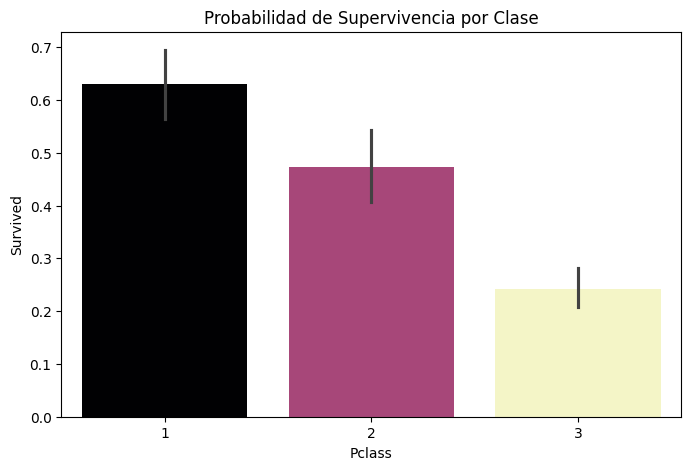

In [3]:
plt.figure(figsize=(8,5))
sns.barplot(
    x='Pclass',
    y='Survived',
    hue='Pclass',
    data=df,
    palette='magma',
    legend=False
)
plt.title('Probabilidad de Supervivencia por Clase')
plt.show()

# Distribución de Edades

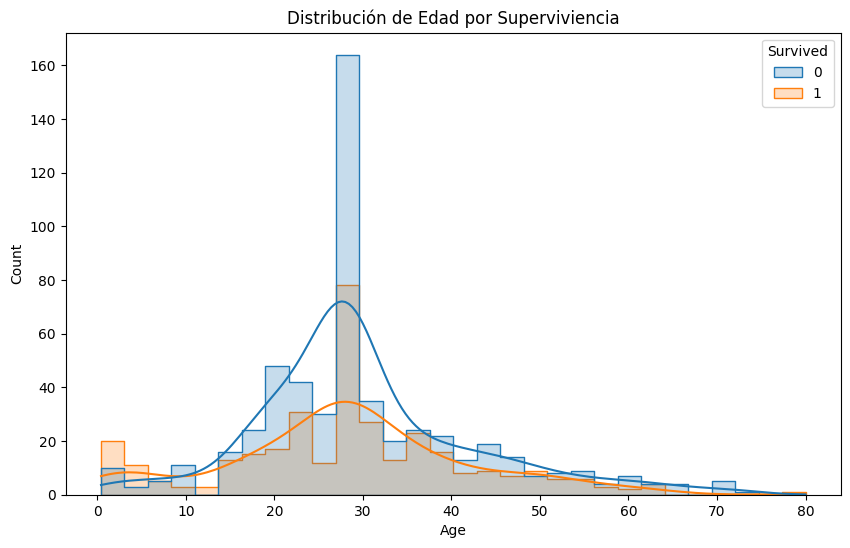

In [4]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Age', hue= 'Survived', kde=True, element='step')
plt.title('Distribución de Edad por Superviviencia')
plt.show()

In [5]:
df['Sex'] = df['Sex'].map({'male': 0, 'female':1})

df = pd.get_dummies(df, columns=['Embarked'], prefix='Emb')

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Emb_C,Emb_Q,Emb_S
0,0,3,0,22.0,1,0,7.2500,False,False,True
1,1,1,1,38.0,1,0,71.2833,True,False,False
2,1,3,1,26.0,0,0,7.9250,False,False,True
3,1,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,0,35.0,0,0,8.0500,False,False,True


In [6]:
df.to_csv('data/titanic_feature.csv', index= False)

print("Datos guardados en data/titanic_feature.csv")

Datos guardados en data/titanic_feature.csv


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

df = pd.read_csv('data/titanic_feature.csv')

x = df.drop('Survived', axis=1)
y = df['Survived']



In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('data/titanic_clean.csv')
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [9]:
df.sample(4)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
639,0,3,male,28.0,1,0,16.10,S
489,1,3,male,9.0,1,1,15.90,S
99,0,2,male,34.0,1,0,26.00,S
157,0,3,male,30.0,0,0,8.05,S


In [10]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

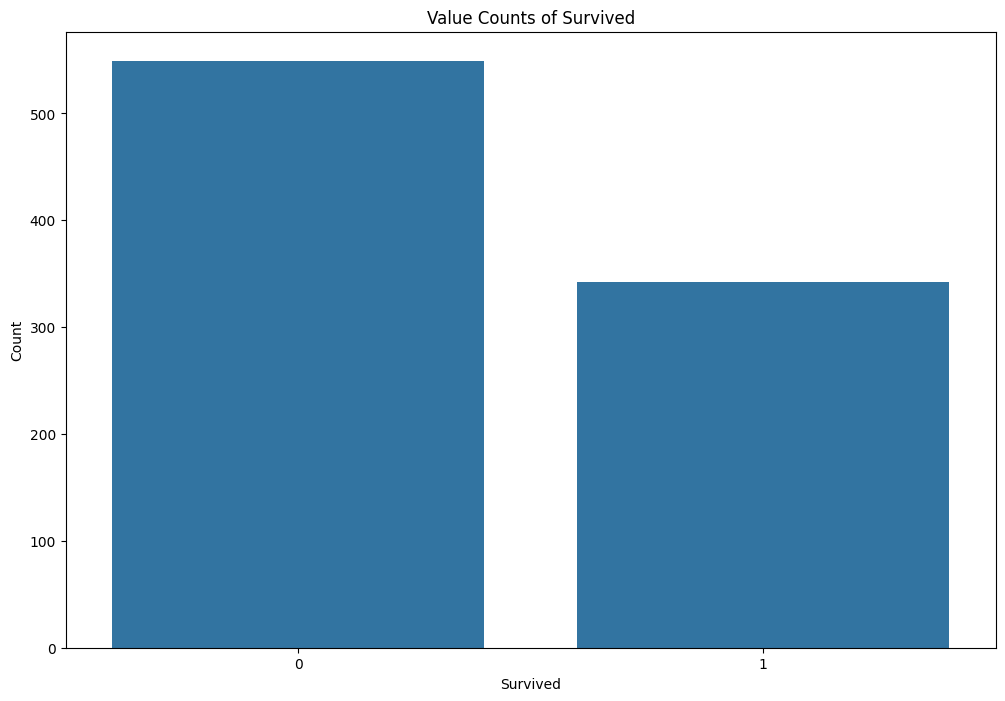

In [11]:
plt.figure(figsize=(12,8))

sns.barplot(
    x=df['Survived'].value_counts().index,
    y=df['Survived'].value_counts()
)

plt.title('Value Counts of Survived')
plt.xlabel('Survived')
plt.ylabel('Count')

plt.show()

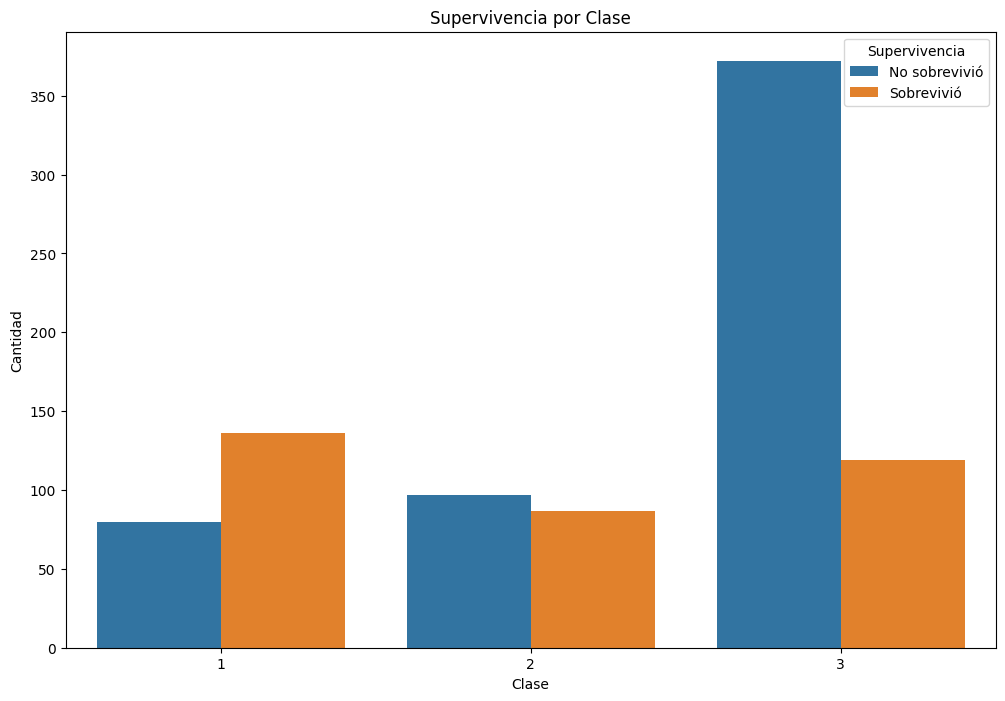

In [12]:
plt.figure(figsize=(12,8))

sns.countplot(
    data=df,
    x='Pclass',
    hue='Survived'
)

plt.title('Supervivencia por Clase')
plt.xlabel('Clase')
plt.ylabel('Cantidad')

plt.legend(
    title='Supervivencia',
    labels=['No sobrevivió', 'Sobrevivió']
)

plt.show()

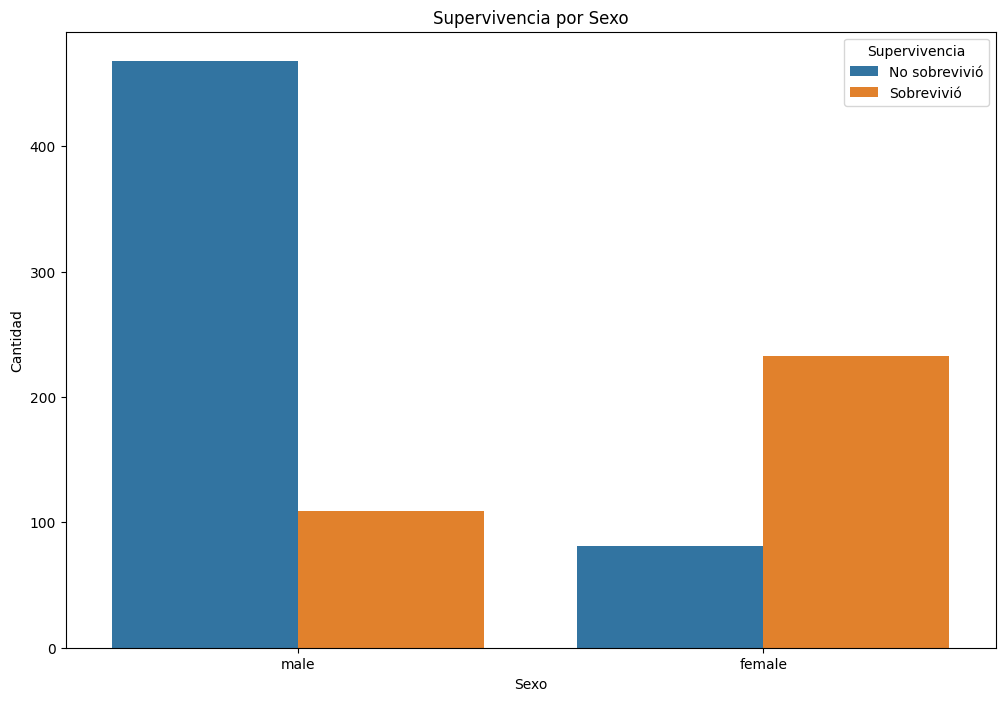

In [13]:
plt.figure(figsize=(12,8))

sns.countplot(
    data=df,
    x='Sex',
    hue='Survived'
)

plt.title('Supervivencia por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Cantidad')

plt.legend(
    title='Supervivencia',
    labels=['No sobrevivió', 'Sobrevivió']
)

plt.show()

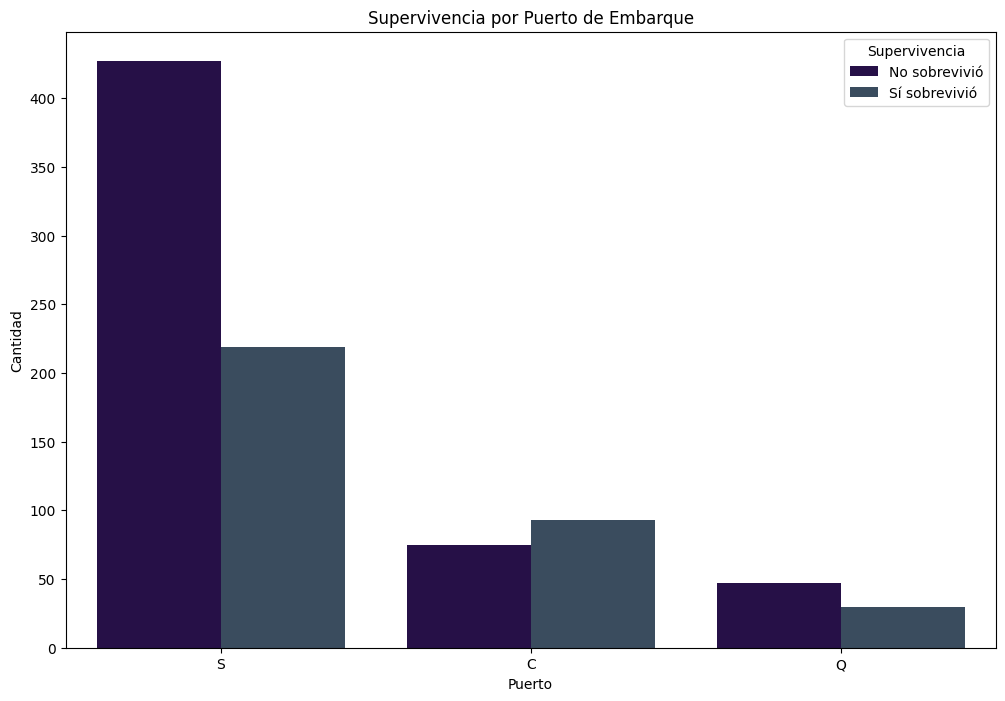

In [14]:
plt.figure(figsize=(12,8))

color = ['#240750', '#344C64']

sns.countplot(
    data=df,
    x='Embarked',
    hue='Survived',
    palette=color
)

plt.title('Supervivencia por Puerto de Embarque')
plt.xlabel('Puerto')
plt.ylabel('Cantidad')

plt.legend(
    title='Supervivencia',
    labels=['No sobrevivió', 'Sí sobrevivió']
)

plt.show()

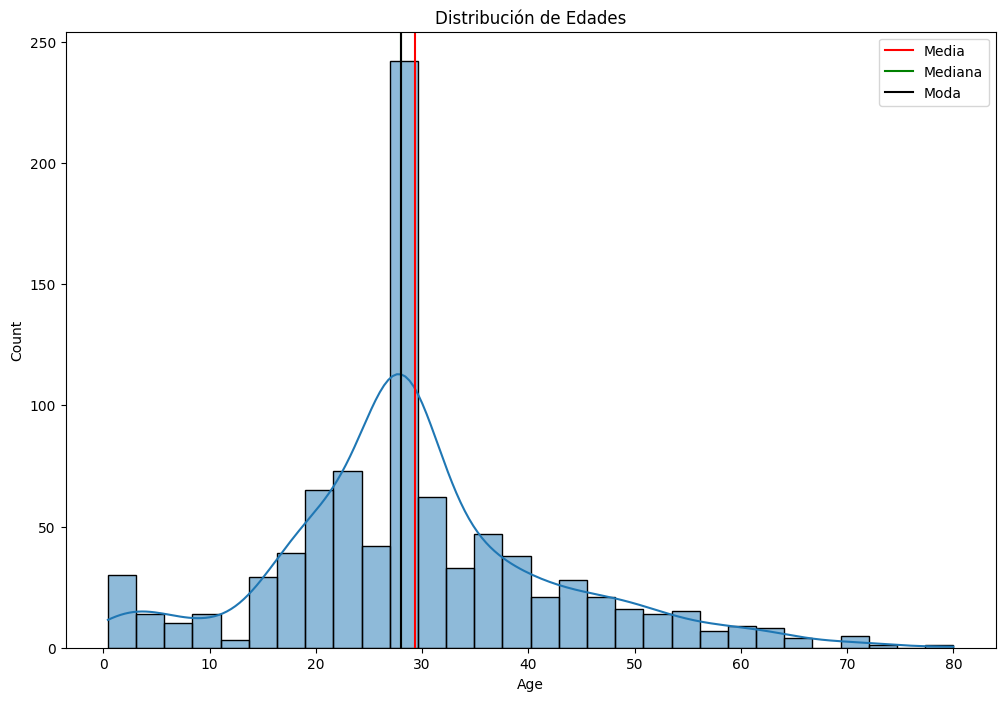

In [15]:
plt.figure(figsize=(12,8))

sns.histplot(df, x='Age', kde=True)

plt.title('Distribución de Edades')

plt.axvline(df['Age'].mean(), color='red', label='Media')
plt.axvline(df['Age'].median(), color='green', label='Mediana')
plt.axvline(df['Age'].mode()[0], color='black', label='Moda')

plt.legend()

plt.show()

In [16]:
print(f"Media: {df['Age'].mean()}")
print(f"Mediana: {df['Age'].median()}")
print(f"Moda: {df['Age'].mode()[0]}")

Media: 29.36158249158249
Mediana: 28.0
Moda: 28.0


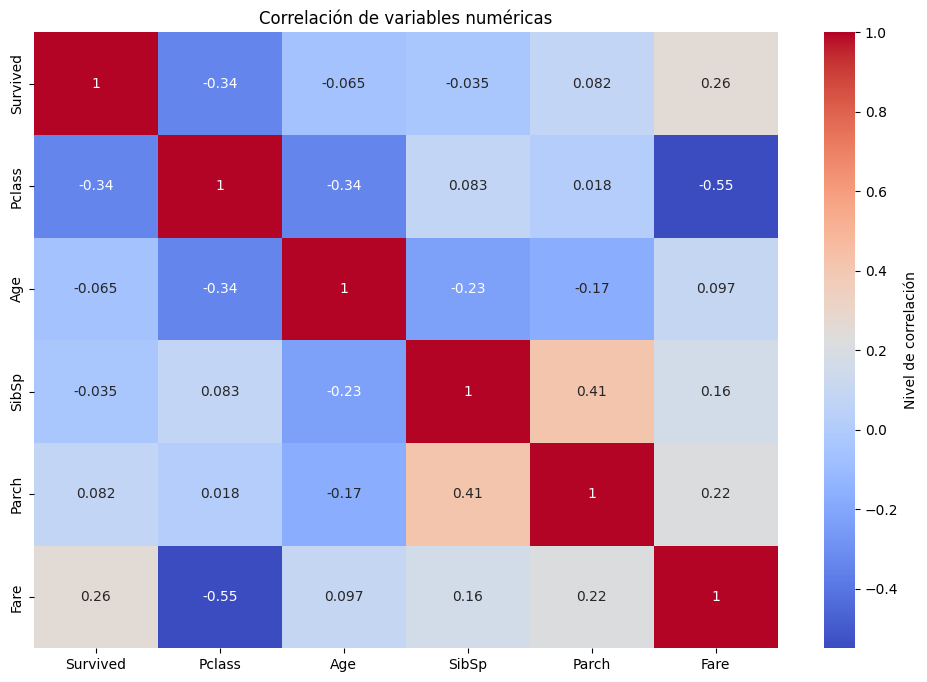

In [17]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr(),
    annot=True,
    cbar=True,
    cmap='coolwarm',
    cbar_kws={'label': 'Nivel de correlación'}
)

plt.title('Correlación de variables numéricas')

plt.show()

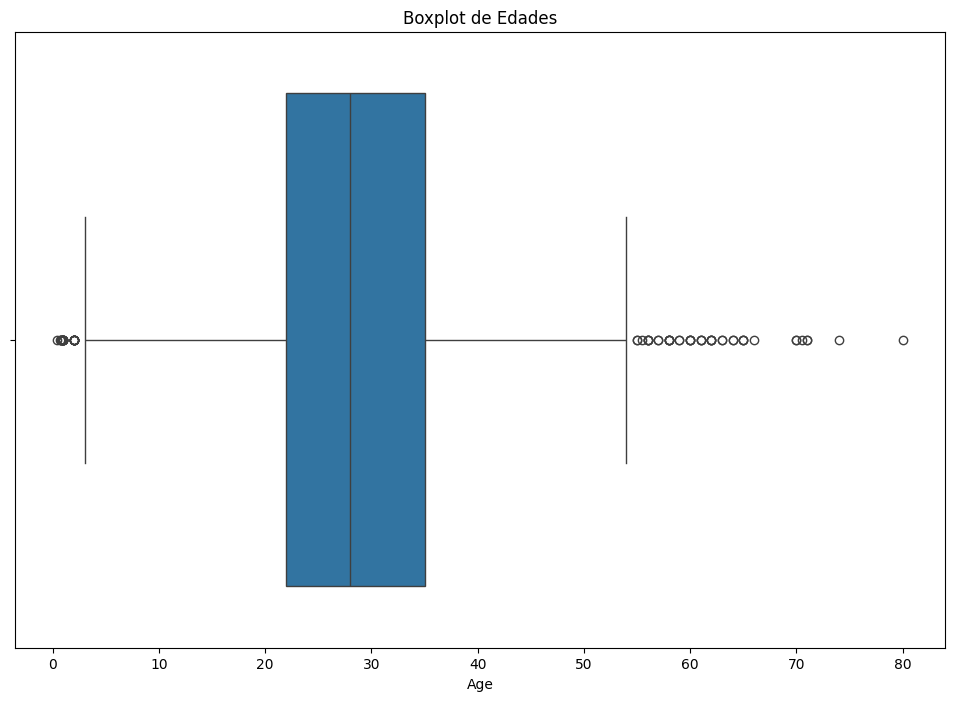

In [18]:
plt.figure(figsize=(12,8))

sns.boxplot(x=df['Age'])

plt.title('Boxplot de Edades')

plt.show()

In [19]:
print(f"Máximo Fare: {df['Fare'].max()}")
print(f"Mínimo Fare: {df['Fare'].min()}")

Máximo Fare: 512.3292
Mínimo Fare: 0.0


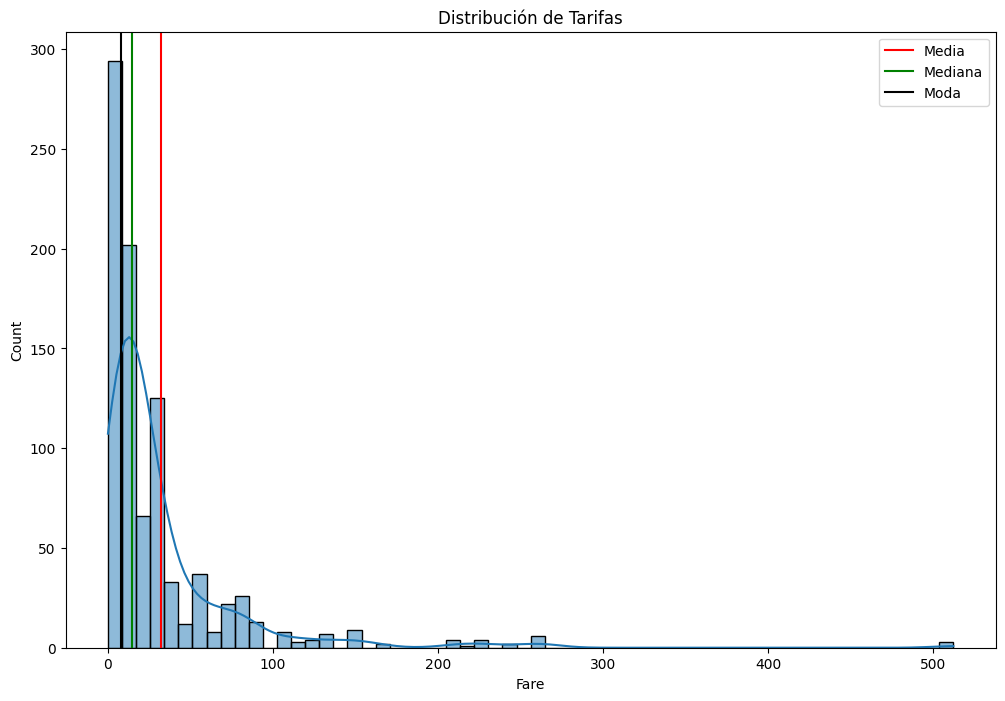

In [20]:
plt.figure(figsize=(12,8))

sns.histplot(df, x='Fare', kde=True)

plt.title('Distribución de Tarifas')

plt.axvline(df['Fare'].mean(), color='red', label='Media')
plt.axvline(df['Fare'].median(), color='green', label='Mediana')
plt.axvline(df['Fare'].mode()[0], color='black', label='Moda')

plt.legend()

plt.show()

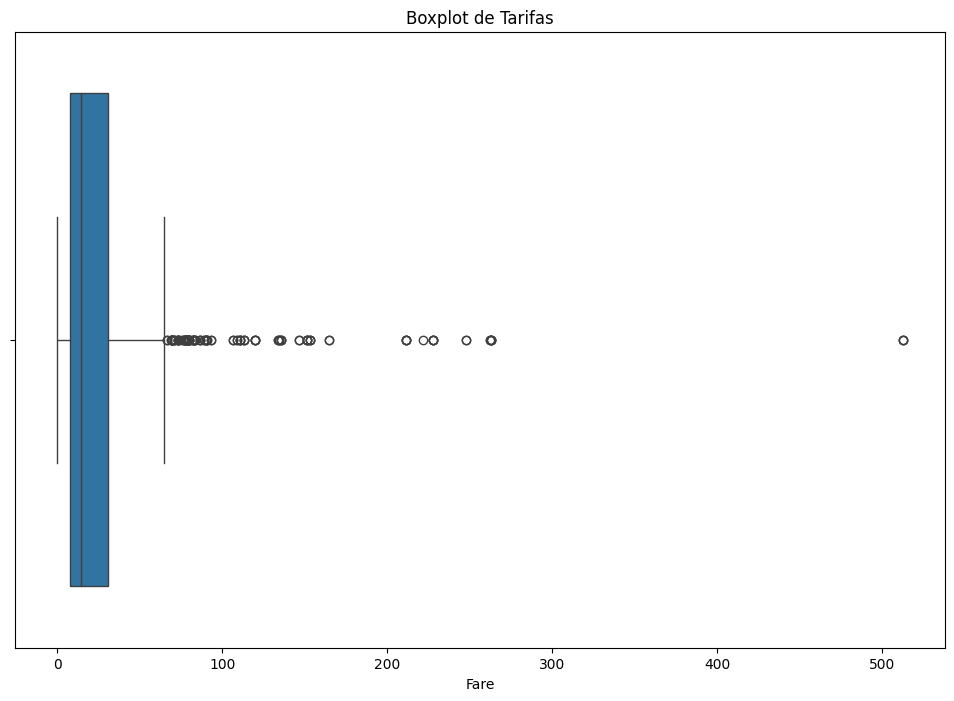

In [21]:
plt.figure(figsize=(12,8))

sns.boxplot(x=df['Fare'])

plt.title('Boxplot de Tarifas')

plt.show()

In [22]:
df[df['Fare'] == 0]

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
179,0,3,male,36.0,0,0,0.0,S
263,0,1,male,40.0,0,0,0.0,S
271,1,3,male,25.0,0,0,0.0,S
277,0,2,male,28.0,0,0,0.0,S
302,0,3,male,19.0,0,0,0.0,S
413,0,2,male,28.0,0,0,0.0,S
466,0,2,male,28.0,0,0,0.0,S
481,0,2,male,28.0,0,0,0.0,S
597,0,3,male,49.0,0,0,0.0,S
633,0,1,male,28.0,0,0,0.0,S


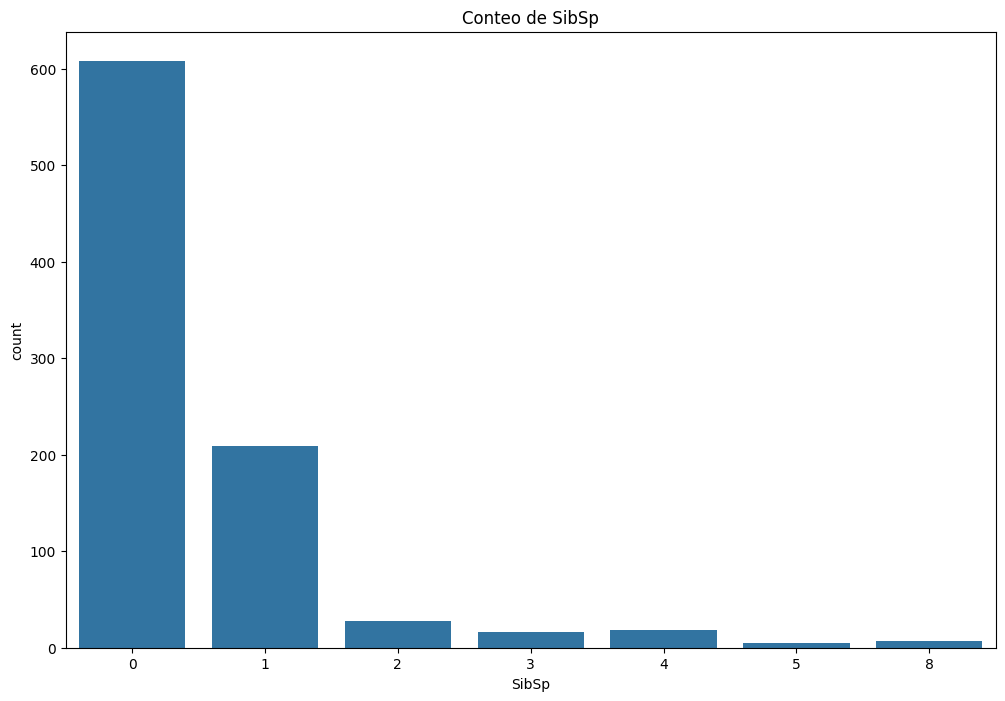

In [23]:
plt.figure(figsize=(12,8))

sns.countplot(data=df, x='SibSp')

plt.title('Conteo de SibSp')

plt.show()

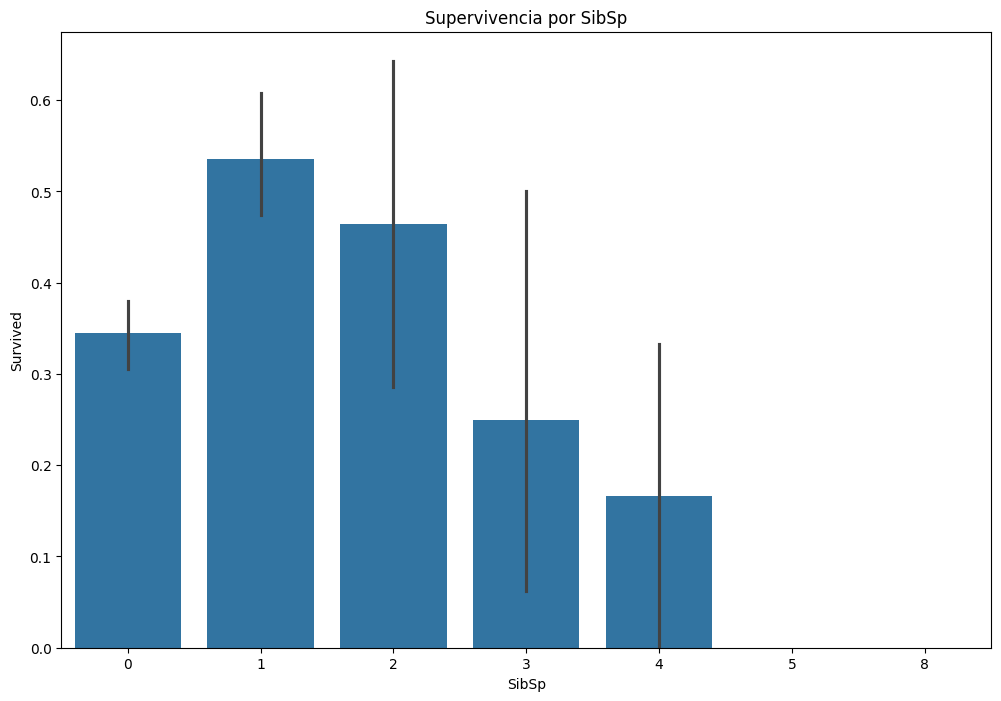

In [24]:
plt.figure(figsize=(12,8))

sns.barplot(data=df, x='SibSp', y='Survived')

plt.title('Supervivencia por SibSp')

plt.show()

In [25]:
survival_rate = df.groupby('SibSp')['Survived'].mean() * 100

print(survival_rate)

SibSp
0    34.539474
1    53.588517
2    46.428571
3    25.000000
4    16.666667
5     0.000000
8     0.000000
Name: Survived, dtype: float64


In [26]:
df.sample(4)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
592,0,3,male,47.0,0,0,7.2500,S
822,0,1,male,38.0,0,0,0.0000,S
285,0,3,male,33.0,0,0,8.6625,C
257,1,1,female,30.0,0,0,86.5000,S


In [27]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

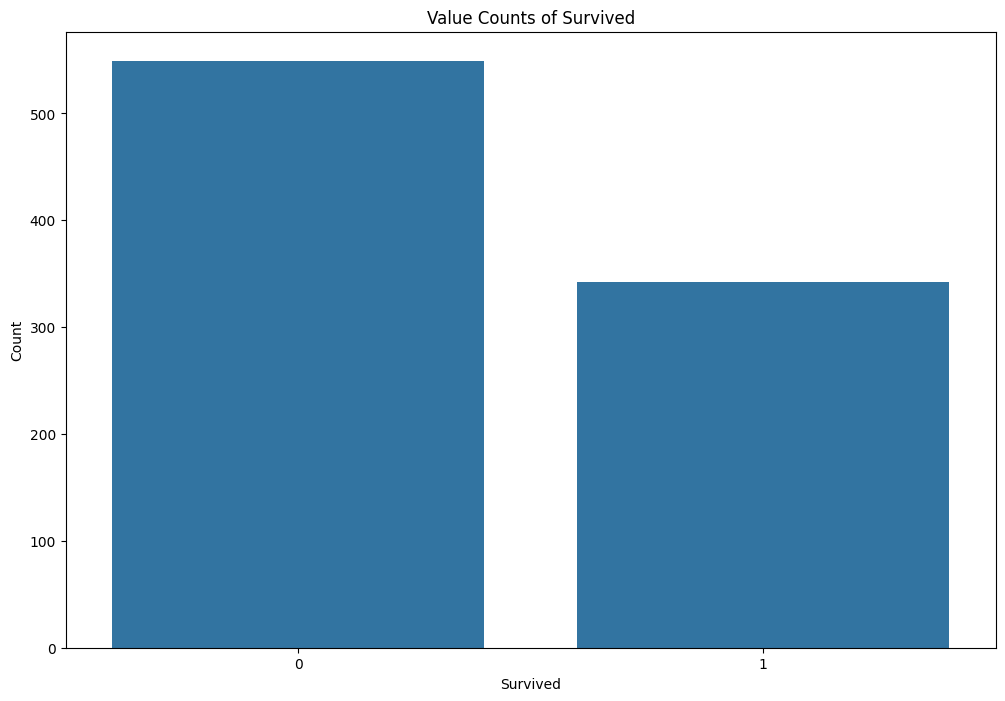

In [28]:
plt.figure(figsize=(12, 8))

sns.barplot(
    x=df['Survived'].value_counts().index,
    y=df['Survived'].value_counts()
)

plt.title('Value Counts of Survived')
plt.xlabel('Survived')
plt.ylabel('Count')

plt.show()

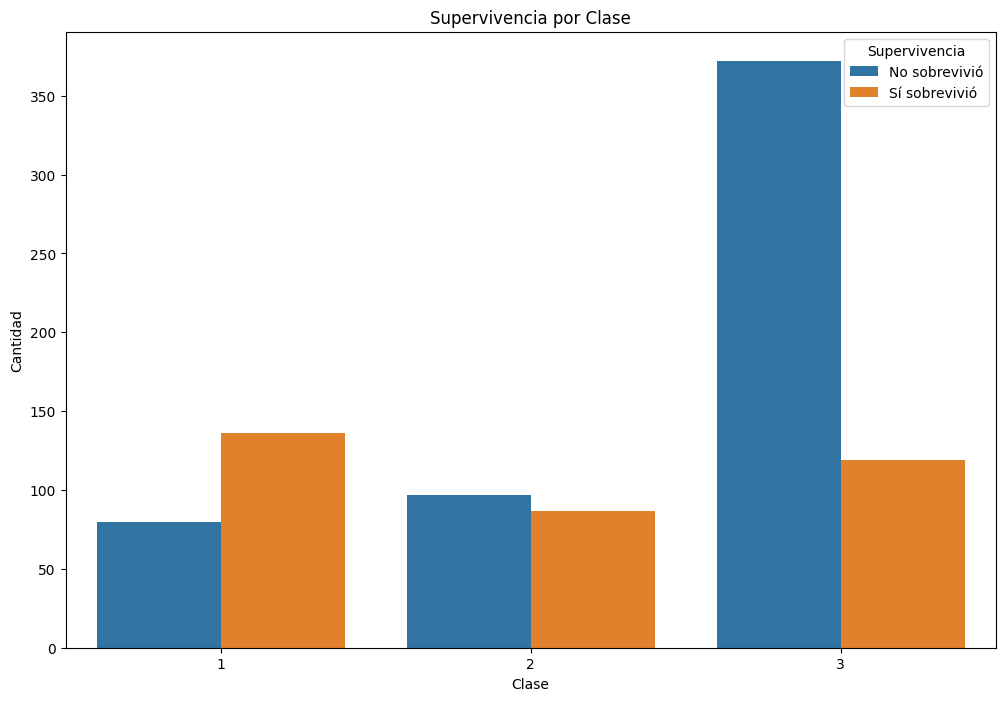

In [29]:
plt.figure(figsize=(12, 8))

sns.countplot(
    data=df,
    x='Pclass',
    hue='Survived'
)

plt.title('Supervivencia por Clase')
plt.xlabel('Clase')
plt.ylabel('Cantidad')

plt.legend(
    title='Supervivencia',
    labels=['No sobrevivió', 'Sí sobrevivió']
)

plt.show()

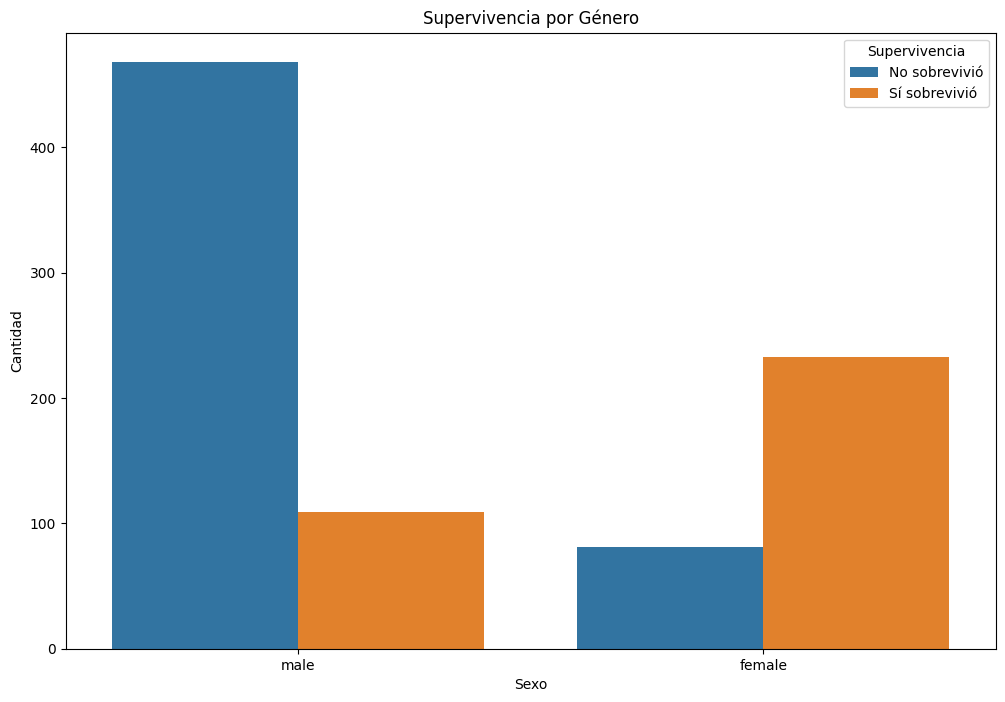

In [30]:
plt.figure(figsize=(12, 8))

sns.countplot(
    data=df,
    x='Sex',
    hue='Survived'
)

plt.title('Supervivencia por Género')
plt.xlabel('Sexo')
plt.ylabel('Cantidad')

plt.legend(
    title='Supervivencia',
    labels=['No sobrevivió', 'Sí sobrevivió']
)

plt.show()

In [31]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='str')

In [32]:
df = pd.read_csv('./data/titanic.csv')

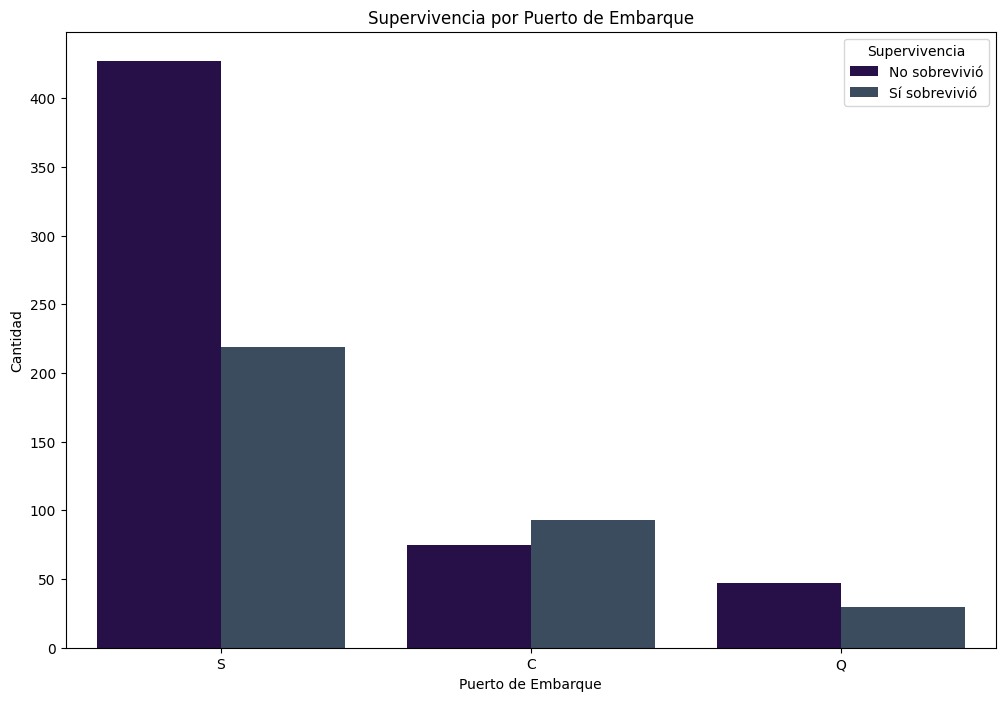

In [33]:
plt.figure(figsize=(12, 8))

color = ['#240750', '#344C64']

sns.countplot(
    data=df,
    x='Embarked',
    hue='Survived',
    palette=color
)

plt.title('Supervivencia por Puerto de Embarque')
plt.xlabel('Puerto de Embarque')
plt.ylabel('Cantidad')

plt.legend(
    title='Supervivencia',
    labels=['No sobrevivió', 'Sí sobrevivió']
)

plt.show()

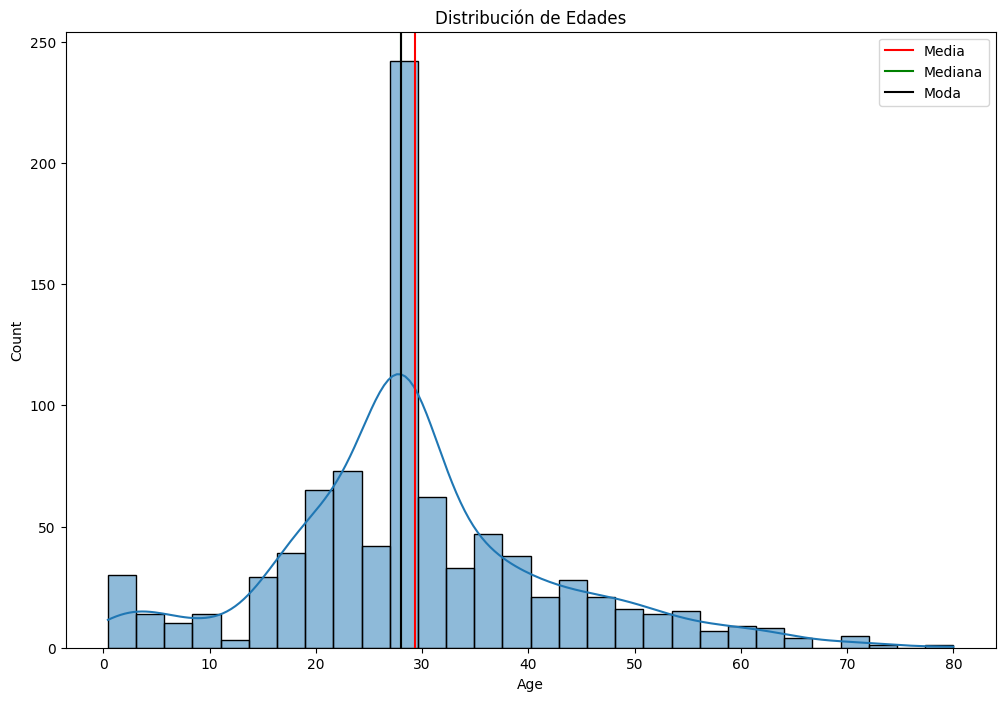

In [34]:
plt.figure(figsize=(12, 8))

sns.histplot(df, x='Age', kde=True)

plt.title('Distribución de Edades')

plt.axvline(df['Age'].mean(), color='red', label='Media')
plt.axvline(df['Age'].median(), color='green', label='Mediana')
plt.axvline(df['Age'].mode()[0], color='black', label='Moda')

plt.legend()

plt.show()

In [35]:
print(f"Media: {df['Age'].mean()}")
print(f"Mediana: {df['Age'].median()}")
print(f"Moda: {df['Age'].mode()[0]}")

Media: 29.36158249158249
Mediana: 28.0
Moda: 28.0


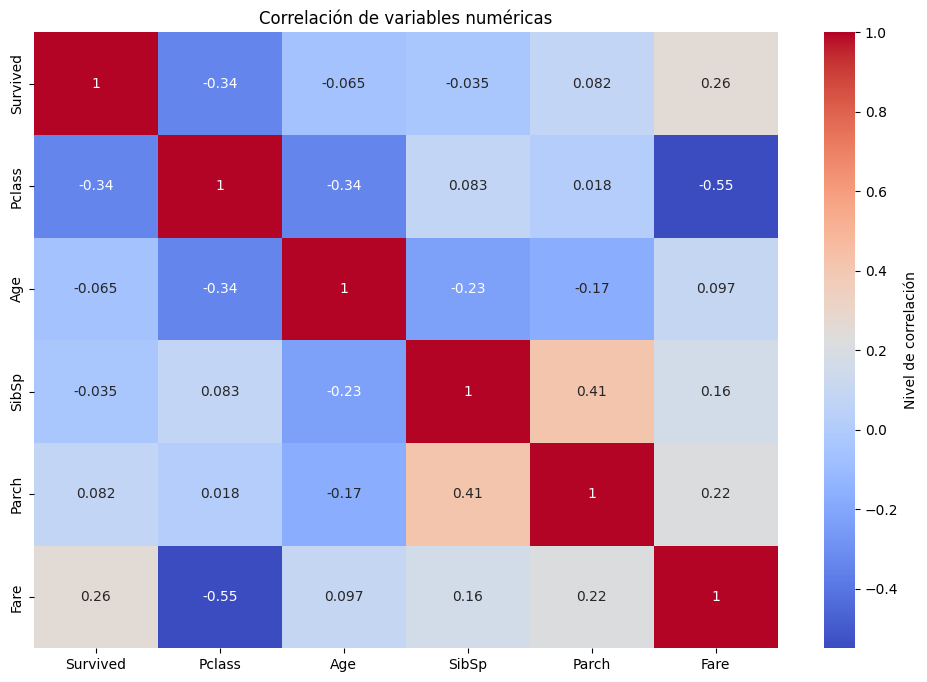

In [36]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr(),
    annot=True,
    cbar=True,
    cmap='coolwarm',
    cbar_kws={'label': 'Nivel de correlación'}
)

plt.title('Correlación de variables numéricas')

plt.show()

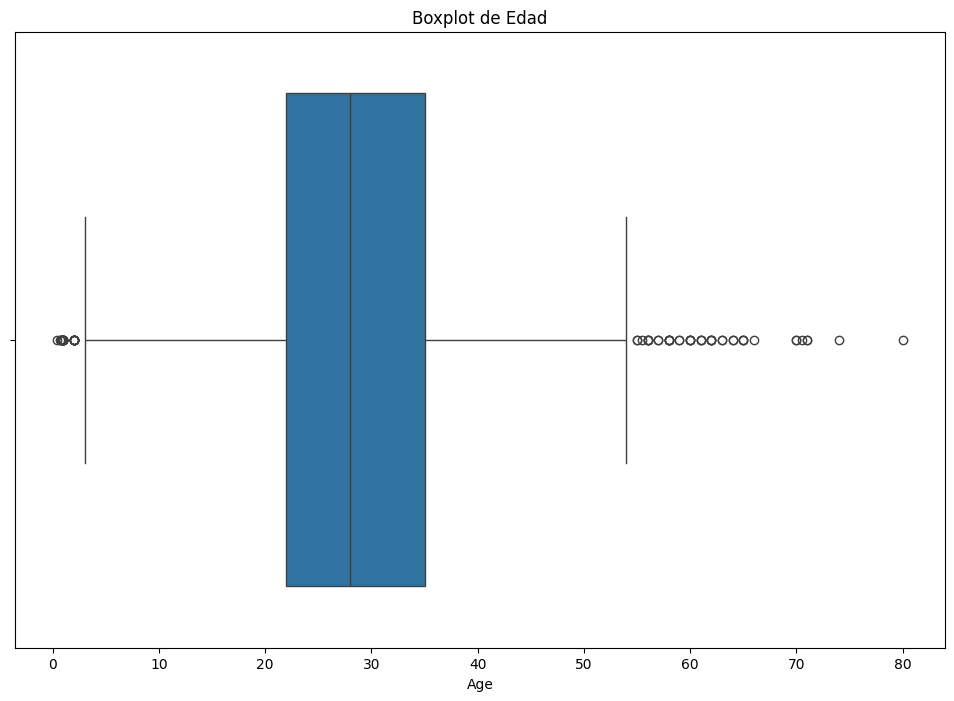

In [37]:
plt.figure(figsize=(12, 8))

sns.boxplot(x=df['Age'])

plt.title('Boxplot de Edad')

plt.show()

In [38]:
print(f"Fare máximo: {df['Fare'].max()}")
print(f"Fare mínimo: {df['Fare'].min()}")

Fare máximo: 512.3292
Fare mínimo: 0.0


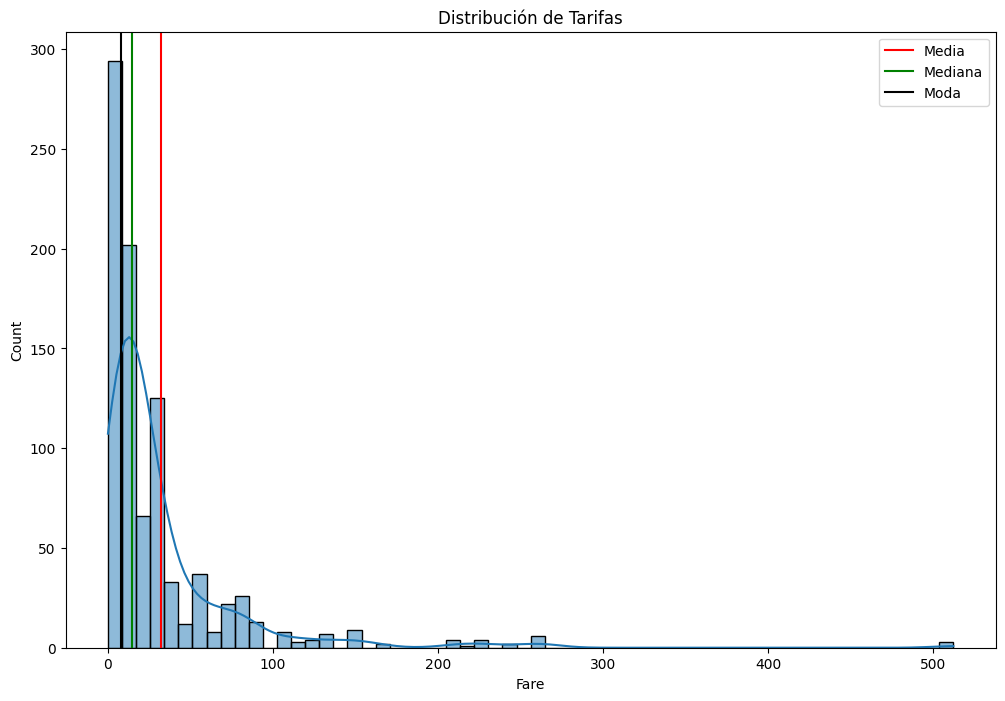

In [39]:
plt.figure(figsize=(12, 8))

sns.histplot(df, x='Fare', kde=True)

plt.title('Distribución de Tarifas')

plt.axvline(df['Fare'].mean(), color='red', label='Media')
plt.axvline(df['Fare'].median(), color='green', label='Mediana')
plt.axvline(df['Fare'].mode()[0], color='black', label='Moda')

plt.legend()

plt.show()

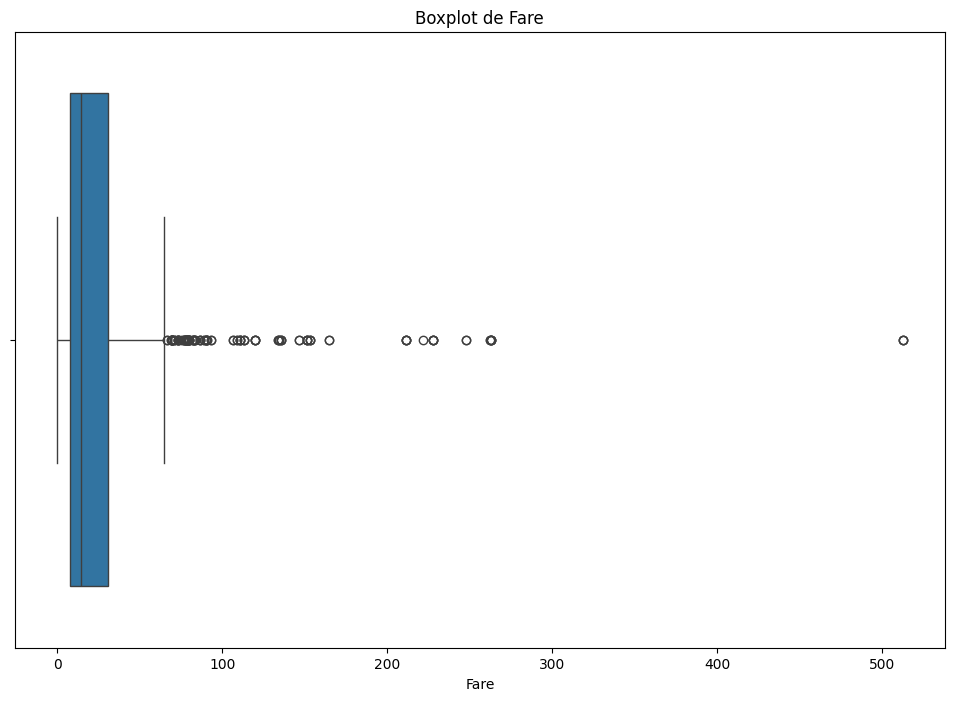

In [40]:
plt.figure(figsize=(12, 8))

sns.boxplot(x=df['Fare'])

plt.title('Boxplot de Fare')

plt.show()

In [41]:
df[df['Fare'] == 0]

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
179,0,3,male,36.0,0,0,0.0,S
263,0,1,male,40.0,0,0,0.0,S
271,1,3,male,25.0,0,0,0.0,S
277,0,2,male,28.0,0,0,0.0,S
302,0,3,male,19.0,0,0,0.0,S
413,0,2,male,28.0,0,0,0.0,S
466,0,2,male,28.0,0,0,0.0,S
481,0,2,male,28.0,0,0,0.0,S
597,0,3,male,49.0,0,0,0.0,S
633,0,1,male,28.0,0,0,0.0,S


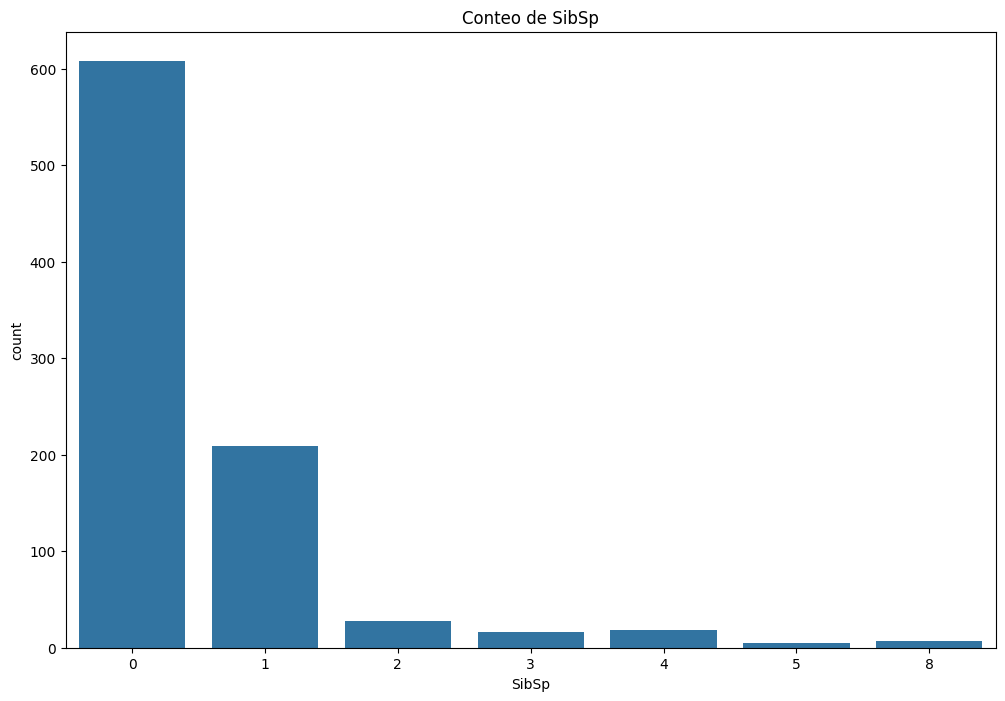

In [42]:
plt.figure(figsize=(12, 8))

sns.countplot(data=df, x='SibSp')

plt.title('Conteo de SibSp')

plt.show()

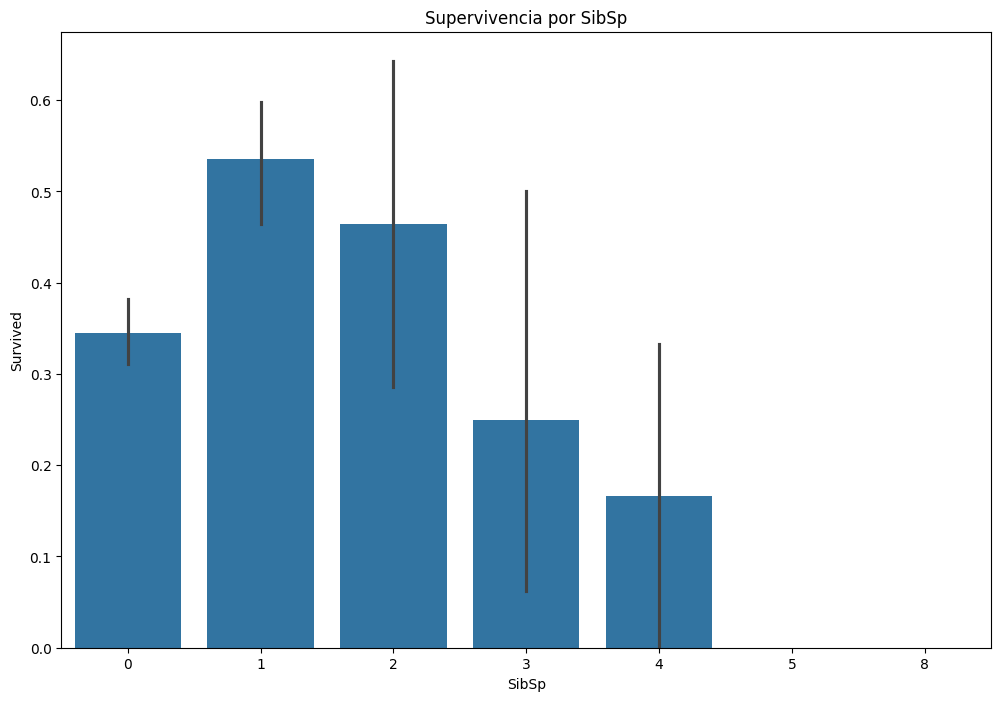

In [43]:
plt.figure(figsize=(12, 8))

sns.barplot(data=df, x='SibSp', y='Survived')

plt.title('Supervivencia por SibSp')

plt.show()

In [44]:
porcentaje_supervivencia = df.groupby('SibSp')['Survived'].mean() * 100

print(porcentaje_supervivencia)

SibSp
0    34.539474
1    53.588517
2    46.428571
3    25.000000
4    16.666667
5     0.000000
8     0.000000
Name: Survived, dtype: float64


In [45]:
# Calcular tasa de supervivencia

survival_rate = df['Survived'].mean() * 100

print(f"Tasa de supervivencia: {survival_rate:.2f}%")

Tasa de supervivencia: 38.38%
